In [10]:
# graph.py
from langgraph.graph import StateGraph, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

In [11]:
load_dotenv()

True

In [10]:
class MessageState(TypedDict):
    sender: str
    message: str
    messageType: str
    reply: str

In [16]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [12]:
# Node 1: Message receive karo
def receive_message(state: MessageState) -> MessageState:
    return state

# Router function — messageType dekho
def route_message(state: MessageState) -> str:
    if state.get("messageType") == "audioMessage":
        return "voice"
    return "text"

In [13]:
class Response(BaseModel):
    responce: str = Field(
        ...,
        description="The response to the user's message."
    )

Response_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful and intelligent assistant.

            ## Language Rule (Most Important)
            - ALWAYS detect the language of the user's message.
            - ALWAYS respond in the EXACT same language the user used.
            - NEVER switch languages unless the user switches first.

            ## Examples

            User: "مرحبا، كيف حالك؟"
            Assistant: "مرحباً! أنا بخير، شكراً لك. كيف يمكنني مساعدتك اليوم؟"

            User: "Hello, what is the capital of France?"
            Assistant: "The capital of France is Paris."

            User: "Mujhe biryani ki recipe chahiye."
            Assistant: "Zaroor! Biryani banane ke liye in cheezон ki zaroorat hogi..."

            User: "¿Cuál es la mejor manera de aprender inglés?"
            Assistant: "La mejor manera de aprender inglés es practicar todos los días..."

            User: "كيف أتعلم البرمجة؟"
            Assistant: "يمكنك تعلم البرمجة من خلال البدء بلغة Python لأنها سهلة للمبتدئين..."

            ## Behavior
            - Be helpful, accurate, and concise.
            - Match the user's tone — formal ya casual jo bhi user use kare.
            - If a message is unclear, ask for clarification in the same language they used."""
        ),
        ("human", "Message: {message}"),
    ]
)

llm_responce = llm.with_structured_output(Response)


# Node 2a: Text process karo
def process_message(state: MessageState):

    message = state.get("message", "")

    response: Response = llm_responce.invoke(Response_prompt.format_prompt(message=message))
    
    return {"reply": response.responce}

In [14]:
# Node 2b: Voice handle karo
def process_voice(state: MessageState):
    reply = "Hey your voice msg received"
    return {"reply": reply}

In [15]:
# Node 3: Reply ready
def send_reply(state: MessageState) -> MessageState:
    return state

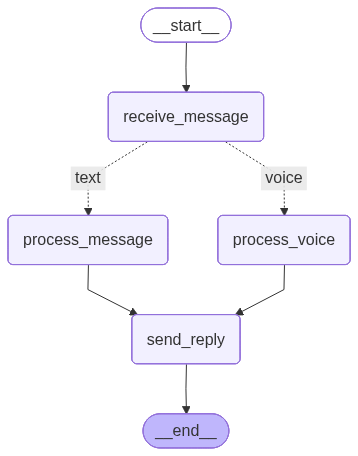

In [16]:
# Graph banao
builder = StateGraph(MessageState)

builder.add_node("receive_message", receive_message)
builder.add_node("process_message", process_message)
builder.add_node("process_voice", process_voice)
builder.add_node("send_reply", send_reply)

builder.set_entry_point("receive_message")

# Conditional edge — router decide karega kaunsa node jayega
builder.add_conditional_edges(
    "receive_message",
    route_message,
    {
        "text": "process_message",
        "voice": "process_voice",
    }
)

builder.add_edge("process_message", "send_reply")
builder.add_edge("process_voice", "send_reply")
builder.add_edge("send_reply", END)

graph = builder.compile()
graph

In [ ]:
# graph.py
from langgraph.graph import StateGraph, END
from typing import TypedDict


class MessageState(TypedDict):
    sender: str
    message: str
    messageType: str
    reply: str

# Node 1: Message receive karo
def receive_message(state: MessageState) -> MessageState:
    print(f"📩 Message aaya from {state['sender']}: {state['message']}")
    return state

# Node 2a: Text process karo (pehle wala kaam)
def process_message(state: MessageState) -> MessageState:
    reply = "Hello! I am from LangGraph 🤖"
    return {**state, "reply": reply}

# Node 2b: Voice handle karo
def process_voice(state: MessageState) -> MessageState:
    reply = "hey your voice msg received"
    return {**state, "reply": reply}

# Node 3: Reply ready
def send_reply(state: MessageState) -> MessageState:
    print(f"📤 Reply ready: {state['reply']}")
    return state

# Router function — messageType dekho
def route_message(state: MessageState) -> str:
    if state.get("messageType") == "audioMessage":
        return "voice"
    return "text"

# Graph banao
builder = StateGraph(MessageState)

builder.add_node("receive_message", receive_message)
builder.add_node("process_message", process_message)
builder.add_node("process_voice", process_voice)
builder.add_node("send_reply", send_reply)

builder.set_entry_point("receive_message")

# Conditional edge — router decide karega kaunsa node jayega
builder.add_conditional_edges(
    "receive_message",
    route_message,
    {
        "text": "process_message",
        "voice": "process_voice",
    }
)

builder.add_edge("process_message", "send_reply")
builder.add_edge("process_voice", "send_reply")
builder.add_edge("send_reply", END)

graph = builder.compile()

In [ ]:
import base64
import tempfile
import os
from openai import OpenAI
from langgraph.graph import END, START, StateGraph
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

In [42]:
class State(TypedDict):
    audio_b64: str

    transcript: str

    reply: str

    audio_bytes: bytes
    response_mimetype: str

In [43]:
# Audio base 64 ko transcribe karne wala node

def transcribe_audio_node(state: State):
    """
    LangGraph node: base64 audio ko transcribe karta hai.
    
    state mein expect karta hai:
        - audio_b64 (str): base64 encoded audio (WhatsApp se receive hua)
    
    state mein add karta hai:
        - transcript (str): transcribed text
    """


    audio_b64 = state["audio_b64"]
    
    # Base64 decode karo
    audio_bytes = base64.b64decode(audio_b64)
    
    # Temp file banao — no manual path management
    with tempfile.NamedTemporaryFile(suffix=".ogg", delete=False) as tmp:
        tmp.write(audio_bytes)
        tmp_path = tmp.name
    
    try:
        with open(tmp_path, "rb") as audio_file:
            result = client.audio.transcriptions.create(
                model="gpt-4o-transcribe",
                file=audio_file
            )
        transcript = result.text
    finally:
        os.unlink(tmp_path)  # cleanup
    
    return {"transcript": transcript}


In [44]:
class Response(BaseModel):
    response: str = Field(
        ...,
        description="The response to the user's message."
    )

Response_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful and intelligent assistant.

            ## Language Rule (Most Important)
            - ALWAYS detect the language of the user's message.
            - ALWAYS respond in the EXACT same language the user used.
            - NEVER switch languages unless the user switches first.

            ## Examples

            User: "مرحبا، كيف حالك؟"
            Assistant: "مرحباً! أنا بخير، شكراً لك. كيف يمكنني مساعدتك اليوم؟"

            User: "Hello, what is the capital of France?"
            Assistant: "The capital of France is Paris."

            User: "Mujhe biryani ki recipe chahiye."
            Assistant: "Zaroor! Biryani banane ke liye in cheezон ki zaroorat hogi..."

            User: "¿Cuál es la mejor manera de aprender inglés?"
            Assistant: "La mejor manera de aprender inglés es practicar todos los días..."

            User: "كيف أتعلم البرمجة؟"
            Assistant: "يمكنك تعلم البرمجة من خلال البدء بلغة Python لأنها سهلة للمبتدئين..."

            ## Behavior
            - Be helpful, accurate, and concise.
            - Match the user's tone — formal ya casual jo bhi user use kare.
            - If a message is unclear, ask for clarification in the same language they used."""
        ),
        ("human", "Message: {message}"),
    ]
)

llm_responce = llm.with_structured_output(Response)


# Node 2a: Text process karo
def process_message(state: State):
    transcription = state["transcript"]

    response: Response = llm_responce.invoke(Response_prompt.format_prompt(message=transcription))
    
    return {"reply": response.response}

In [45]:
def text_to_speech_node(state: State):
    """
    LangGraph node: text ko speech mein convert karta hai.
    
    state mein expect karta hai:
        - tts_input (str): jo text bولنا hai
    
    state mein add karta hai:
        - audio_bytes (bytes): mp3 file ka content
        - audio_path (str): temp file path (agar directly path chahiye)
    """
    text = state["reply"]

    response = client.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="alloy",
        input=text
    )

    # Option 1: bytes state mein store karo
    audio_bytes = response.read()

    # Option 2: temp file mein save karo aur path store karo
    with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as tmp:
        tmp.write(audio_bytes)
        tmp_path = tmp.name

    return {
        "audio_bytes": audio_bytes,   
        "response_mimetype": "audio/mpeg"         
    }

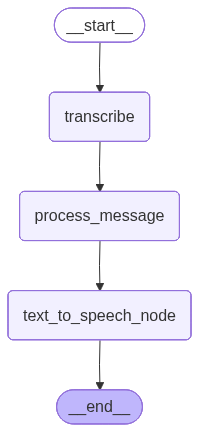

In [46]:
graph = StateGraph(State)

graph.add_node("transcribe", transcribe_audio_node)
graph.add_node("process_message", process_message)
graph.add_node("text_to_speech_node", text_to_speech_node)

graph.add_edge(START, "transcribe")
graph.add_edge("transcribe","process_message")
graph.add_edge("process_message","text_to_speech_node")
graph.add_edge("text_to_speech_node",END)

graph = graph.compile()
graph

In [47]:
basefile = "T2dnUwACAAAAAAAAAAAAAAAAAAAAACqCBoIBE09wdXNIZWFkAQFoAIA+AAAAAABPZ2dTAAAAAAAAAAAAAAAAAAABAAAAjzLsvAEYT3B1c1RhZ3MIAAAAV2hhdHNBcHAAAAAAT2dnUwAAKF0BAAAAAAAAAAAAAgAAAIIQSeMSP+bu/wL6+vT6/wbz9PTe+cBqWhMC+TBIiLHj46QIiN9cB627UBGyAfJcif5vGNG+qjq8oSRd/OAlC+oxUJ5N5kohSOMNUpJ2BskFzLocsxx+Wm7hwhg8oCvbEU9pxmDpiyqY37ZvzGZ9EJU3zO1kbc/y46nb7WORDZkuS5Gxnx/iVDobWc7pwwWSv/mZyFFRImciKv59QUIsZIOFve9w2N40OBaeJRdl1+pNYvv0WpqHCsc+W9mBCzhCeqHmbH+DgOBBpRlB/AjjyvhOEL9WJMlEQmj5LNTcDcQ+eo7QtIuk04cYmDZdg/tPd8NJUqCBhLCaY0+Z9xyIkjsnhwVwnN4B08RPiV/V6VHfs6DLp8dON8lYk0vaxndxSxE2w680jnO2ipM2rSUJou4iltU1joS5czCdK7RaeOJpj5KkBel8DVeJ4cX/UbWg8Q5yPLiFDNEueQ3mojqO9nbS8ZvmCS0RvWj/DBkT+8NyZgb1HxwNHZg96EjxK6oqVOwIMbNlZ/9NGGn1bEa+shVdt4UUzGvU+CWM3yni8SWjhMtcd8+ug0lTWVsSih5wiyuh+x3eHuB0GtSM/BsLAmYJIJ5JosrLyMzvrk6UYsJ2Smql2dvKSKys8MG8T6txtJXNSDIqV3p7GC3EnRn6aNS7wP+/p+UP4lEDJMPyVPLet8TrAcDbkepGVCnI7p2cJerLg3ClBa3fk9DpzDKgdN3vMnGhu3XoLNegWoHjk10MqhuCpcjWkl7uCKx/5t6sVEcZDM3h/AkUpS5KBL68ucZeqiw64YLkBYKY82MZewK78FSonZNpuQT3PvMK6DbHXkgCwsLuXPGk/MStiqP1Z/iKJhwuxahKd+ed39LxPeDxxldG7icQGM0DNHWd8HBpkopWt6Jg/BKe/cC6OEDj91Fyo9bxyLF3M+WmWL0tV2a9sQ6zngTnlaAQqdW4a4VNLF0doqu+XXUqzjLB7XZ21zQ9Gfhr83KzM0FbjvhQiQCf3EKVtGR8rHsvVI7l/jj4DRr48l+7mI7IhtIz+IGZWO+0nNxBTVe6YoSS92b+oyJmyrLY+DkB6bnEakBae+Rcvvlv/CH+5ENaI1Sb0+8LX5sN+Wfs1KphTcRXJMMIL/UWVop8wCziE+78zMwTCzsHn7oLlRVV//Aq0rEs18qtI/L1KPoH+HzpwApnAhQR77uLx9+PsjxtZF5XapJjHWTUUmSd3glESgiWytUptKjsgM3EPgKaA+zrfOSGOeMmj1dHPnq4Q90TelN/pERe+7ct12UkA4FYM7UC8AA7exHlHGa5/gBNPM8pOu7LTfbRMrqfraVs1Ug1OnkcsV2jLYg5xoZUo1q9adlVMU0MRFUpK1EITrrYMBWvef/oI+SC+hp2yZgVAX2IMIsljPPLT36Xpzap9BIQWnfhBrr9nmybAKQz+hVtH8F6turE9sCltg02Sx6APf5Igr1FxF55a/fK6pfYJkOjMyodbmNU5LCPyTZFCBuHvyEPv5ap4D5W0gn/YUQcT8uYglwYYKjQAbSUsxm9L5cg1DYtBbcGpLRrvtoMrYcY910M4U2LRlYtRuVEVWdXa9kgehn4OSIoujVYu7rdaR6IKvdmUEYNJvYlCSTrBBYVfhTYLDbYrRWBjwVyO/OHVDMyxwlz+Bm5W+zgiqvI5WKwdrVEd94NN3kkaE1qut4eFU8yJ9+m4F82135AEpF9wAAe2Srln6Q6iz9JTYWX+63QguS7Bl1rrBFLcFp74XNB3M8XzFtWQr6v1rPYnuex66c27vd8uoNcmm+ib7qjKHyBVFqj9ZfmhePSZHgr4iaCaaNQsigHrKso2JGFAf03Dn/xzu304To+JgSlx54Ry9RMx+9lEJ8LFXLduskWL7KJSGTR/qkmND4991Hyz31TcUbByAgodWFA4WTIp6QkyWiLfAzRngO46xFXWtYJ5AP6C0Hdf7KkbaMTjIiRJaowXLBC37KX9hTpLfnCIpwKQunDG7TVe4KUXpgSt6VzqaHX2WrWMggziPOrLCEwPdOQhvA0FyF7ZvHxSeuFdjac6L+BIVyI3Ven3TyM41edlkBadu3cXGpeZ/FRqfgyKGP3zz7DoxZ/xUgPZnJ1To/y7rBs4EBZSfXA//Q2d7nPO6VcPGQ9VyLAlWjgwalC87K9Y/yaiX6IxrCDKN8Zr4LHeIa9j+Scfy/UWmCs9Qkf9NiB1IWioeaWHCnpmihaTZ1Qeck5K7SV5yTs7WgqtnjT63o4M9s1UdnrG496OpMsDPNueKIhevG8DEwlKT42lcA6ZI3VtdWjs50555AejTw2+v3lXJyQ/+y2tejClOWSp3k/t4BBijFIWn0DQgV/I3G4GyZUid17nnRGEbsUODjs+v5ivaiUBkLkUOt1PmrYhI+HQpMOHcCKVligWn7rsskYIu1kljO7dXbzNmoVZyMnAqj9gYX8d756HhCTXEWO4DEz6zgHT7HBoURed2m0YGVmal/jtdwbHWYmkKxG9Nd40sdXVapIwLp6452F6JEWU+s3JcvhDB+CLcdql2iuU1zmodPJqhRUP3z0Jjybv26pT6uqwXWQFob4rGDtMZmIDWPP0EGmWoTSHzQTrfpk77AuMT4WUmwqib+lorkWOwSXchG3MBkrR+twKrOe6b8W4FdL1duWfRU5LpWj+Bbmnian9L/gFIqjp7au09wWhHH3AEuPr6Mr+58557s1q1xkVtWoeE1zHyvEgctrTy49EWOEcQmTuu/mCmAQlbe4uL2AWnPp9uK7eXOGFiQMfM/dp14ojA0lhYQ13IqTSsdy1Y8mVnKmsb9OFnKmYJpBu03x4S54PZiSJFdCP4zcF0hH8UPPzy8oe7Ub/CVPDzNcQzjTQzIf3qVlqH35ehq8AYC1xbzwzJ09Xfe7R9LACmn4s+0TfuvQ4PH/F7Cxjnf0c4WWjD5RzjWfEkxQyJWQsyMQtd7O/oduCLiUa/exyyurK+L/o/ZnC7rr3upeH73J3C/ynSEjTJxwyrNGxDvqVc97bF1A2j/qEQE0c0G9UJ/O6rOeeNLWjBNHZEBP5sJWCg7BaITv/DCif+GcBci3ST5vyDpgWoHrhf53Kh8O8C1xdD+FPdLPBnJoMN4ua2xkQshNSaKXjc/1/KxGa9VQKHSdZjQbVp7yBDck03E1dc88aqVbHzS/jI4ZtWHvGyTDMubUShKki7PGq78PbABPQe/yrijKNfMjy5ncB/rya8wRS3BXp7F2tVY5pdsY998DYTRyboXV3JTKWP6BqIX/OGeUQ7nG/bEEHoKof4ks3pqUrpLtPMmD73e1p3jHTWejja6k35ktL4xCFglVHyeb9qb1EfrZV6T6WMXjEJnN9xXNeGIA0qTWPR/Ys+B75nrjQuDhY/1zXWy97uBwM4jSWK2JeYa74IFPgFp34M0+h6osaRjIlFHw2Ib1cK23F4+NPxhe/TuiaFxJiNy3Z+tH1M/q+jRvYt5JeiTFKi/qm/XhwZodxpuj2DOfqjb3sXKWl/OIXnX4LA8w+y7ts8J63zw7CRup7bHfDd49pS6Cs/HPI1YgaSofoC0gXwpXzjVWs8DtkJuCJqSJ1J559KlAsZuz9pqFU7GFIVcBXLE1T+9UK91M44DFNlnU0WevPPcMbWPC04Jn2amEMNudm08j20TiHdIZXNqgqu6VrUr1q1UvCWascb7RALWCpdfvQ/pzkwu0Zj1HaJQYVuQ5oR0+tpsDXmmuygAoUJDPJ9haduz3KPlQRdavBxJ6qK159DJOyLaL/GzUAFp0s8Cg8cfg7VuU3BIdyFKEYGUSLKU/xJaXKoOWc4CTSdQN/pIzhzzG3wnPbN6ib/Tnxbc6/sVMg9+gMltx51eAS7h/VbxINUQf1NCTnWO5kzxlmYGvPAQiH4MUJEDsDS0G9d26HM5g6iyJLMyhYZLlumM3n8Biomjj90yH+DOaWPF8rt+XK1nPmTGjAsVftPRtC3KGlUfb7ARNVHw2M829O1c8hCYxG1IiUhp85dIhWL8GHyY4N/RrgbBYyZuGe5zojIBae+v2IsSW4Ztp7uW3dHQ34RyJ8Y85DzgsrDlT1K1Zi1JYjEJzwH/acsqOYzeftekfeb9R+x+XLdwpZjaPnQPYQvGsYIhEf4lmJ62O77PWtu+Fg5KFhigjjY4M1uVbZoRtaXXrENEnMOwIm8Mniw3IMNgQO7qBGbG4rBaS0OmWbglu93PybJdXnDr90hSs36sUvvA5NHHyJE0jGXDq1qH1/R7IgIGIP3xYPZFUuDetIT+eAWLIdBcKF+NPmcPQJjBTIqQVZdFqIvMNeoq4eHFvk0Wix7fyIZZCT30w9EWDkxR65kMIA6H+yeRoSApnMfk0taPsTcFzV2RaYYDVXWflTgg9ZEmdMSVSLhit7wtK4wKM+wz6VpCfqozLiij8o70nH3Dgi5sOXpe5MMDTDgh/ZKPEz1BHFGVD3dNeqyvFo8bb5Tr/0FQpJCliLak+TuugSihosqujdzcYZqAOosg5/vVO1DSwawpRzRZ61PWUApr5OdLBSs0V1L72/0wKBRPQkcue4OCiRs5uxHbjOKiYz/zV789IaeL/oehjj+LETlTlNq6ThfoQWyOBFwOZf//DOpo/TNqx7IBYDjqTzeQwaYGhU+oaCokmEaC+rUwfH6wqdzVRDLPIzGxlJf+zM+9JNcEqApz1D5G7RGfQFAhGxxzjtIfRc02zCgjNVCA7dn+eoLXpqaw8hxLYgAftZcSOOT7IArZa4UWCZvEYRL1grSpA"

result = graph.invoke({"audio_b64": basefile})


In [48]:
result

{'audio_b64': 'T2dnUwACAAAAAAAAAAAAAAAAAAAAACqCBoIBE09wdXNIZWFkAQFoAIA+AAAAAABPZ2dTAAAAAAAAAAAAAAAAAAABAAAAjzLsvAEYT3B1c1RhZ3MIAAAAV2hhdHNBcHAAAAAAT2dnUwAAKF0BAAAAAAAAAAAAAgAAAIIQSeMSP+bu/wL6+vT6/wbz9PTe+cBqWhMC+TBIiLHj46QIiN9cB627UBGyAfJcif5vGNG+qjq8oSRd/OAlC+oxUJ5N5kohSOMNUpJ2BskFzLocsxx+Wm7hwhg8oCvbEU9pxmDpiyqY37ZvzGZ9EJU3zO1kbc/y46nb7WORDZkuS5Gxnx/iVDobWc7pwwWSv/mZyFFRImciKv59QUIsZIOFve9w2N40OBaeJRdl1+pNYvv0WpqHCsc+W9mBCzhCeqHmbH+DgOBBpRlB/AjjyvhOEL9WJMlEQmj5LNTcDcQ+eo7QtIuk04cYmDZdg/tPd8NJUqCBhLCaY0+Z9xyIkjsnhwVwnN4B08RPiV/V6VHfs6DLp8dON8lYk0vaxndxSxE2w680jnO2ipM2rSUJou4iltU1joS5czCdK7RaeOJpj5KkBel8DVeJ4cX/UbWg8Q5yPLiFDNEueQ3mojqO9nbS8ZvmCS0RvWj/DBkT+8NyZgb1HxwNHZg96EjxK6oqVOwIMbNlZ/9NGGn1bEa+shVdt4UUzGvU+CWM3yni8SWjhMtcd8+ug0lTWVsSih5wiyuh+x3eHuB0GtSM/BsLAmYJIJ5JosrLyMzvrk6UYsJ2Smql2dvKSKys8MG8T6txtJXNSDIqV3p7GC3EnRn6aNS7wP+/p+UP4lEDJMPyVPLet8TrAcDbkepGVCnI7p2cJerLg3ClBa3fk9DpzDKgdN3vMnGhu3XoLNegWoHjk10MqhuCpcjWkl7uCKx/5t6sVEcZDM3h/AkUpS5KBL68ucZeqiw64YLkBYKY82MZewK78FSonZNpuQT3P

In [49]:
print(result["audio_b64"])
print(result["response_mimetype"])

T2dnUwACAAAAAAAAAAAAAAAAAAAAACqCBoIBE09wdXNIZWFkAQFoAIA+AAAAAABPZ2dTAAAAAAAAAAAAAAAAAAABAAAAjzLsvAEYT3B1c1RhZ3MIAAAAV2hhdHNBcHAAAAAAT2dnUwAAKF0BAAAAAAAAAAAAAgAAAIIQSeMSP+bu/wL6+vT6/wbz9PTe+cBqWhMC+TBIiLHj46QIiN9cB627UBGyAfJcif5vGNG+qjq8oSRd/OAlC+oxUJ5N5kohSOMNUpJ2BskFzLocsxx+Wm7hwhg8oCvbEU9pxmDpiyqY37ZvzGZ9EJU3zO1kbc/y46nb7WORDZkuS5Gxnx/iVDobWc7pwwWSv/mZyFFRImciKv59QUIsZIOFve9w2N40OBaeJRdl1+pNYvv0WpqHCsc+W9mBCzhCeqHmbH+DgOBBpRlB/AjjyvhOEL9WJMlEQmj5LNTcDcQ+eo7QtIuk04cYmDZdg/tPd8NJUqCBhLCaY0+Z9xyIkjsnhwVwnN4B08RPiV/V6VHfs6DLp8dON8lYk0vaxndxSxE2w680jnO2ipM2rSUJou4iltU1joS5czCdK7RaeOJpj5KkBel8DVeJ4cX/UbWg8Q5yPLiFDNEueQ3mojqO9nbS8ZvmCS0RvWj/DBkT+8NyZgb1HxwNHZg96EjxK6oqVOwIMbNlZ/9NGGn1bEa+shVdt4UUzGvU+CWM3yni8SWjhMtcd8+ug0lTWVsSih5wiyuh+x3eHuB0GtSM/BsLAmYJIJ5JosrLyMzvrk6UYsJ2Smql2dvKSKys8MG8T6txtJXNSDIqV3p7GC3EnRn6aNS7wP+/p+UP4lEDJMPyVPLet8TrAcDbkepGVCnI7p2cJerLg3ClBa3fk9DpzDKgdN3vMnGhu3XoLNegWoHjk10MqhuCpcjWkl7uCKx/5t6sVEcZDM3h/AkUpS5KBL68ucZeqiw64YLkBYKY82MZewK78FSonZNpuQT3PvMK6DbHXkgCwsLu